# Predicción Meteorológica con Redes Neuronales (RNN y LSTM)
**Harold Styven Lagares De Voz - Deep Learning**

En este notebook, desarrollaremos un modelo de predicción de series temporales utilizando arquitecturas RNN y LSTM. A diferencia de usar APIs externas, trabajaremos con un dataset proporcionado por el profesor, proveniente de una estación meteorológica.

## Fases del Proyecto:
1. **ETL (Extract, Transform, Load):** Limpieza, filtrado y estructuración temporal.
2. **EDA (Exploratory Data Analysis):** Análisis de correlación, estacionalidad y tendencias.
3. **Preprocesamiento:** Escalado y generación de secuencias para Deep Learning.
4. **Modelado y Entrenamiento:** Construcción de modelos SimpleRNN y LSTM.
5. **Evaluación y Predicción:** Comparativa de rendimiento y proyecciones futuras (Aportando valor al negocio).

In [1]:
# Importación de librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# Configuración visual
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 1. Fase ETL (Extract, Transform, Load)

### 1.1 Extracción de los datos
Cargamos el archivo CSV.

In [2]:
# Carga del dataset (Reemplaza con el nombre exacto de tu archivo)
file_path = 'ambient-weather-20241218-20250312.csv'
df = pd.read_csv(file_path)

# Mostrar las primeras filas y dimensiones
print(f"Dimensiones del dataset original: {df.shape}")
display(df.head())

Dimensiones del dataset original: (24302, 32)


,Date,Simple Date,Outdoor Temperature (°C),Feels Like (°C),Dew Point (°C),Wind Speed (km/hr),Wind Gust (km/hr),Max Daily Gust (km/hr),Wind Direction (°),Event Rain (mm),...,Indoor Humidity (%),Avg Wind Direction (10 mins) (°),Outdoor Battery,Absolute Pressure (mmHg),Indoor Battery,Indoor Feels Like (°C),Indoor Dew Point (°C),PM2.5 Indoor,PM2.5 Indoor 24 Hour Average,PM2.5 Indoor Battery
0,2025-03-12T22:30:00-05:00,2025-03-12 22:30:00,27.4,30.3,23.0,6.5,10.8,24.5,267.0,6553.5,...,68.0,113.0,1.0,759.2,1.0,30.9,21.8,670.0,670.0,NaN
1,2025-03-12T22:25:00-05:00,2025-03-12 22:25:00,27.4,30.2,22.8,3.2,11.2,24.5,338.0,6553.5,...,68.0,240.0,1.0,759.3,1.0,30.8,21.7,670.0,670.0,NaN
2,2025-03-12T22:20:00-05:00,2025-03-12 22:20:00,27.4,30.2,22.8,6.8,11.2,24.5,162.0,6553.5,...,68.0,193.0,1.0,759.4,1.0,30.8,21.7,670.0,670.0,NaN
3,2025-03-12T22:15:00-05:00,2025-03-12 22:15:00,27.4,30.2,22.8,4.0,7.6,24.5,138.0,6553.5,...,68.0,279.0,1.0,759.4,1.0,30.8,21.7,670.0,670.0,NaN
4,2025-03-12T22:10:00-05:00,2025-03-12 22:10:00,27.4,30.3,23.0,5.4,7.2,24.5,219.0,6553.5,...,68.0,244.0,1.0,759.5,1.0,30.8,21.7,670.0,670.0,NaN


### 1.2 Transformación Inicial: Limpieza y Formato Temporal
Para que un modelo predictivo meteorológico generalice bien, debemos eliminar variables de control de la estación (como niveles de batería) y variables de interiores (Indoor), ya que estas últimas están alteradas por el ser humano (ej. aire acondicionado) y solo añadirán ruido a nuestra red neuronal.

In [3]:
# 1. Parsear la columna de fecha a formato datetime
df['Date'] = pd.to_datetime(df['Date'])

# 2. Establecer la fecha como índice (Vital para Series Temporales)
df.set_index('Date', inplace=True)

# 3. Eliminar la columna 'Simple Date' si existe (es redundante)
if 'Simple Date' in df.columns:
    df.drop(columns=['Simple Date'], inplace=True)

# 4. Filtrado Inteligente de Columnas:
# Nos quedamos solo con lo que importa para el clima EXTERIOR
cols_to_drop = [col for col in df.columns if 'Indoor' in col or 'Battery' in col or 'PM2.5' in col]
df_weather = df.drop(columns=cols_to_drop)

# Limpiar nombres de columnas para que sean más fáciles de manejar (quitar unidades entre paréntesis)
import re
df_weather.columns = [re.sub(r'\s*\(.*?\)\s*', '', col).strip().replace(' ', '_').lower() for col in df_weather.columns]

print(f"Dimensiones del dataset después de limpiar ruido: {df_weather.shape}")
print("\nColumnas útiles resultantes:")
print(df_weather.columns.tolist())
display(df_weather.head())

Dimensiones del dataset después de limpiar ruido: (24302, 19)

Columnas útiles resultantes:
['outdoor_temperature', 'feels_like', 'dew_point', 'wind_speed', 'wind_gust', 'max_daily_gust', 'wind_direction', 'event_rain', 'rain_rate', 'daily_rain', 'weekly_rain', 'monthly_rain', 'yearly_rain', 'relative_pressure', 'humidity', 'ultra-violet_radiation_index', 'solar_radiation', 'avg_wind_direction', 'absolute_pressure']


,outdoor_temperature,feels_like,dew_point,wind_speed,wind_gust,max_daily_gust,wind_direction,event_rain,rain_rate,daily_rain,weekly_rain,monthly_rain,yearly_rain,relative_pressure,humidity,ultra-violet_radiation_index,solar_radiation,avg_wind_direction,absolute_pressure
Date,,,,,,,,,,,,,,,,,,,
2025-03-12 22:30:00-05:00,27.4,30.3,23.0,6.5,10.8,24.5,267.0,6553.5,NaN,NaN,NaN,NaN,NaN,759.2,77.0,0.0,0.0,113.0,759.2
2025-03-12 22:25:00-05:00,27.4,30.2,22.8,3.2,11.2,24.5,338.0,6553.5,NaN,NaN,NaN,NaN,NaN,759.3,76.0,0.0,0.0,240.0,759.3
2025-03-12 22:20:00-05:00,27.4,30.2,22.8,6.8,11.2,24.5,162.0,6553.5,NaN,NaN,NaN,NaN,NaN,759.4,76.0,0.0,0.0,193.0,759.4
2025-03-12 22:15:00-05:00,27.4,30.2,22.8,4.0,7.6,24.5,138.0,6553.5,NaN,NaN,NaN,NaN,NaN,759.4,76.0,0.0,0.0,279.0,759.4
2025-03-12 22:10:00-05:00,27.4,30.3,23.0,5.4,7.2,24.5,219.0,6553.5,NaN,NaN,NaN,NaN,NaN,759.5,77.0,0.0,0.0,244.0,759.5


### 1.3 Remuestreo Temporal (Resampling)
Los datos están tomados cada pocos minutos. Las redes LSTM son excelentes para capturar memoria a largo plazo, pero si le pasamos datos minuto a minuto para predecir el clima del día siguiente, el gradiente se desvanecerá.

Para solucionar esto y aportar valor real (por ejemplo, predicciones para agricultura o logística), vamos a remuestrear los datos a **frecuencia horaria (1H)** o **diaria (1D)** promediando los valores.

In [4]:
# Vamos a agregar los datos a nivel HORARIO
df_resampled = df_weather.resample('1H').mean()

# Si hay lluvia o eventos acumulativos, la suma tiene más sentido que el promedio.
# Ajustemos específicamente las columnas de lluvia si existen
rain_cols = [col for col in df_resampled.columns if 'rain' in col]
for col in rain_cols:
    df_resampled[col] = df_weather[col].resample('1H').sum()

# Interpolar pequeños valores nulos que hayan quedado por falta de lectura de sensores
df_resampled.interpolate(method='time', inplace=True)
# Si quedan nulos al principio o al final, los llenamos hacia adelante/atrás
df_resampled.fillna(method='bfill', inplace=True)
df_resampled.fillna(method='ffill', inplace=True)

print(f"Dimensiones después del remuestreo horario: {df_resampled.shape}")
print(f"Valores nulos totales: {df_resampled.isnull().sum().sum()}")
display(df_resampled.head())

Dimensiones después del remuestreo horario: (2039, 19)
Valores nulos totales: 0


,outdoor_temperature,feels_like,dew_point,wind_speed,wind_gust,max_daily_gust,wind_direction,event_rain,rain_rate,daily_rain,weekly_rain,monthly_rain,yearly_rain,relative_pressure,humidity,ultra-violet_radiation_index,solar_radiation,avg_wind_direction,absolute_pressure
Date,,,,,,,,,,,,,,,,,,,
2024-12-18 00:00:00-05:00,27.991667,32.808333,25.125000,3.858333,7.400000,10.108333,203.916667,78642.0,0.0,0.0,0.0,0.0,0.0,757.425000,84.666667,0.0,0.0,184.000000,757.425000
2024-12-18 01:00:00-05:00,27.809091,32.381818,25.063636,3.409091,6.709091,11.200000,184.454545,72088.5,0.0,0.0,0.0,0.0,0.0,756.881818,85.181818,0.0,0.0,178.272727,756.881818
2024-12-18 02:00:00-05:00,27.575000,32.025000,25.116667,2.316667,5.200000,11.200000,243.500000,78642.0,0.0,0.0,0.0,0.0,0.0,756.450000,86.500000,0.0,0.0,214.583333,756.450000
2024-12-18 03:00:00-05:00,27.116667,31.200000,25.100000,1.466667,4.200000,11.200000,202.583333,78642.0,0.0,0.0,0.0,0.0,0.0,756.350000,88.833333,0.0,0.0,248.333333,756.350000
2024-12-18 04:00:00-05:00,26.883333,30.550000,24.883333,1.591667,3.650000,11.200000,179.250000,78642.0,0.0,0.0,0.0,0.0,0.0,756.400000,89.000000,0.0,0.0,165.083333,756.400000


## 2. Fase EDA (Exploratory Data Analysis)

### 2.1 Visualización de la Serie Temporal (Tendencia y Estacionalidad)
Vamos a definir nuestra variable objetivo (Target). En predicción meteorológica, la temperatura exterior suele ser la variable principal. Visualizaremos su comportamiento a lo largo del tiempo para identificar patrones cíclicos (estacionalidad diaria).

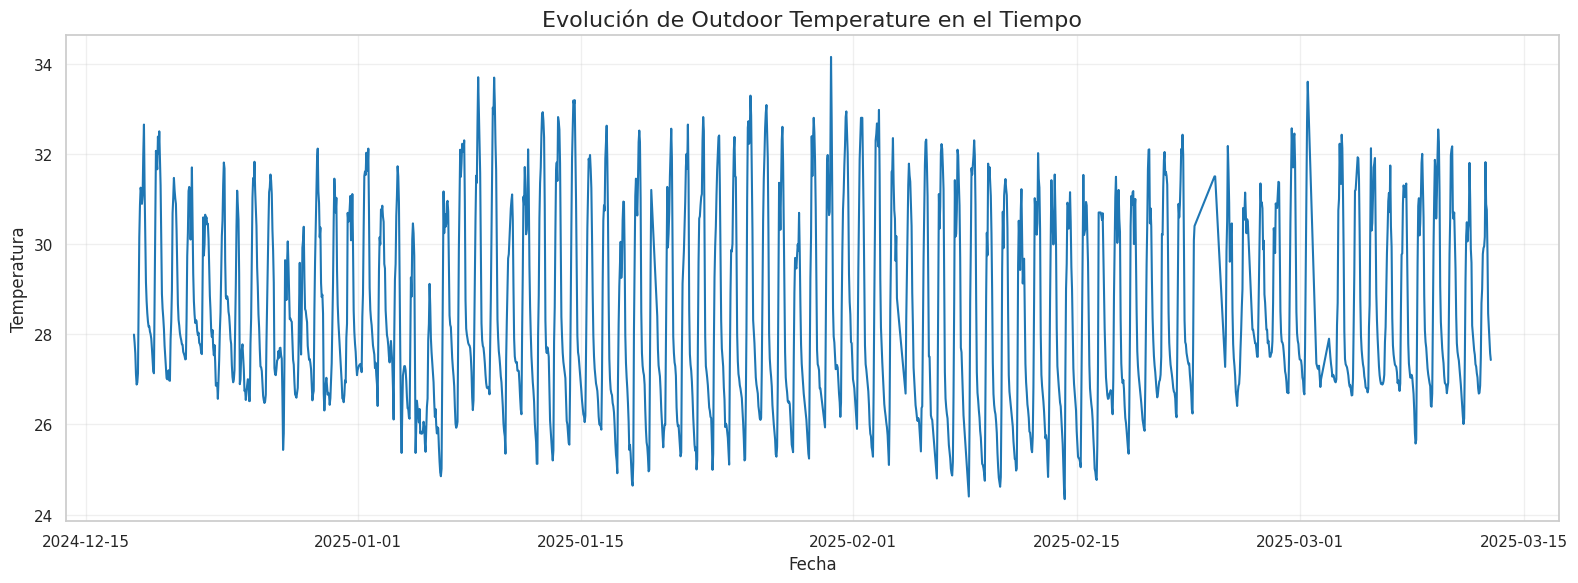

In [5]:
# Definir la variable objetivo
TARGET_VAR = 'outdoor_temperature'

# Verificar si la variable existe, si no, buscar la más parecida
if TARGET_VAR not in df_resampled.columns:
    temp_cols = [col for col in df_resampled.columns if 'temp' in col]
    TARGET_VAR = temp_cols[0] if temp_cols else df_resampled.columns[0]
    print(f"Variable objetivo ajustada automáticamente a: {TARGET_VAR}")

# Crear figura de la serie temporal
plt.figure(figsize=(16, 6))
plt.plot(df_resampled.index, df_resampled[TARGET_VAR], color='#1f77b4', linewidth=1.5)
plt.title(f'Evolución de {TARGET_VAR.replace("_", " ").title()} en el Tiempo', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Temperatura', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Análisis de Correlación Multivariante
Las redes neuronales (como RNN/LSTM) pueden sufrir si les pasamos variables altamente correlacionadas (multicolinealidad), ya que el modelo gasta capacidad de cómputo aprendiendo redundancias.

Por ejemplo, `outdoor_temperature` y `feels_like` (sensación térmica) suelen tener una correlación cercana a 1.0. Detectaremos estas redundancias con un mapa de calor para decidir qué variables descartar antes de modelar.

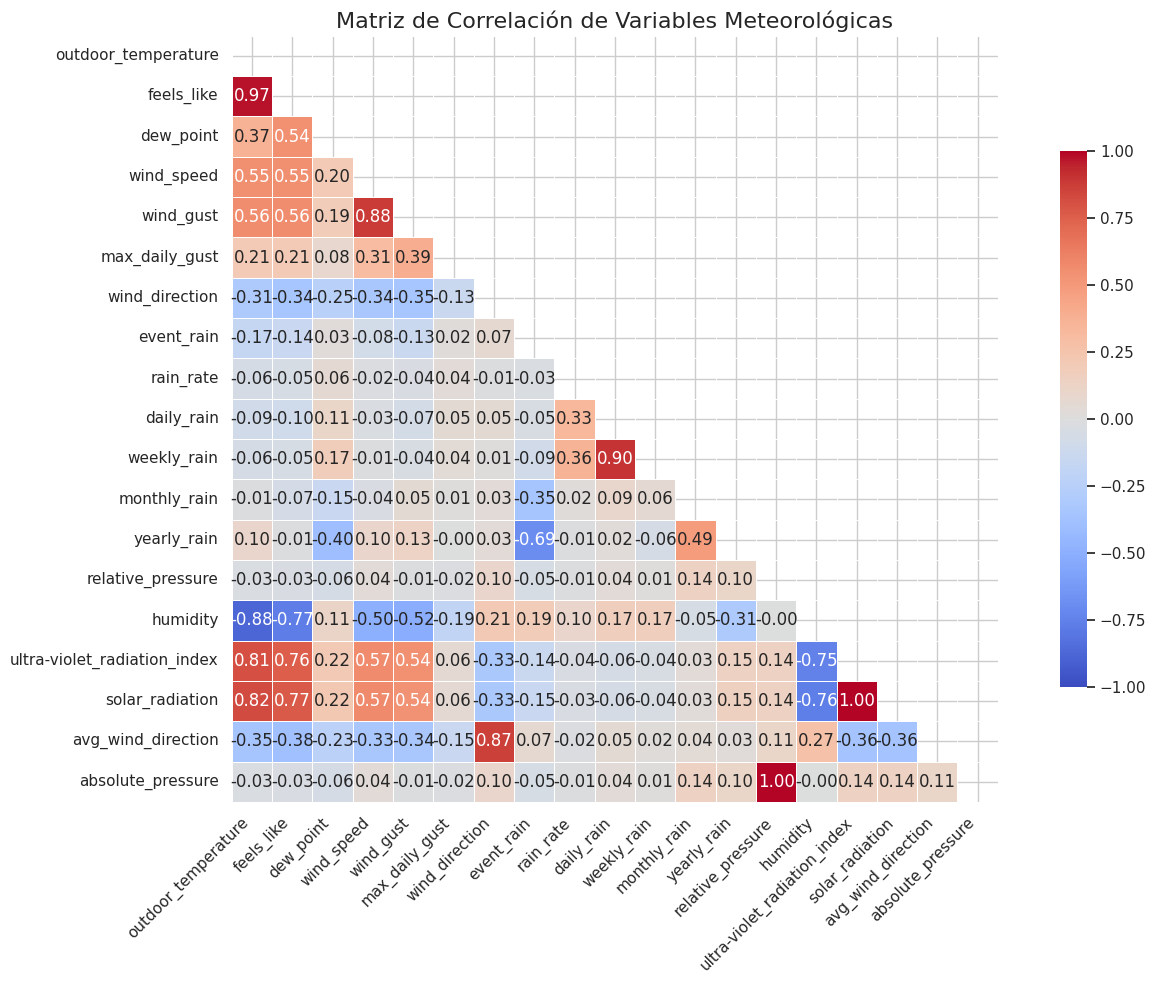

--- Correlación con outdoor_temperature ---
outdoor_temperature             1.000000
feels_like                      0.971678
solar_radiation                 0.822167
ultra-violet_radiation_index    0.807111
wind_gust                       0.557312
wind_speed                      0.548683
dew_point                       0.371459
max_daily_gust                  0.205085
yearly_rain                     0.101227
monthly_rain                   -0.012169
absolute_pressure              -0.027643
relative_pressure              -0.027643
rain_rate                      -0.056570
weekly_rain                    -0.061142
daily_rain                     -0.092119
event_rain                     -0.168898
wind_direction                 -0.306085
avg_wind_direction             -0.352977
humidity                       -0.879971
Name: outdoor_temperature, dtype: float64


In [6]:
# Calcular matriz de correlación
corr_matrix = df_resampled.corr()

# Crear una máscara para ver solo el triángulo inferior (espejo)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .7})
plt.title('Matriz de Correlación de Variables Meteorológicas', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Identificar variables altamente correlacionadas con el Target (>0.8 o <-0.8)
correlations_with_target = corr_matrix[TARGET_VAR].sort_values(ascending=False)
print(f"--- Correlación con {TARGET_VAR} ---")
print(correlations_with_target)

### 2.3 Análisis de Estacionalidad Diaria (Boxplot por Hora)
Para justificar matemáticamente por qué usaremos una ventana de tiempo específica (sequence length) en la LSTM, analizaremos la variabilidad de la temperatura según la hora del día. Si existe un ciclo claro de 24 horas, será fundamental que nuestra red reciba secuencias en múltiplos de 24 (ej. 24, 48 o 72 horas hacia atrás).

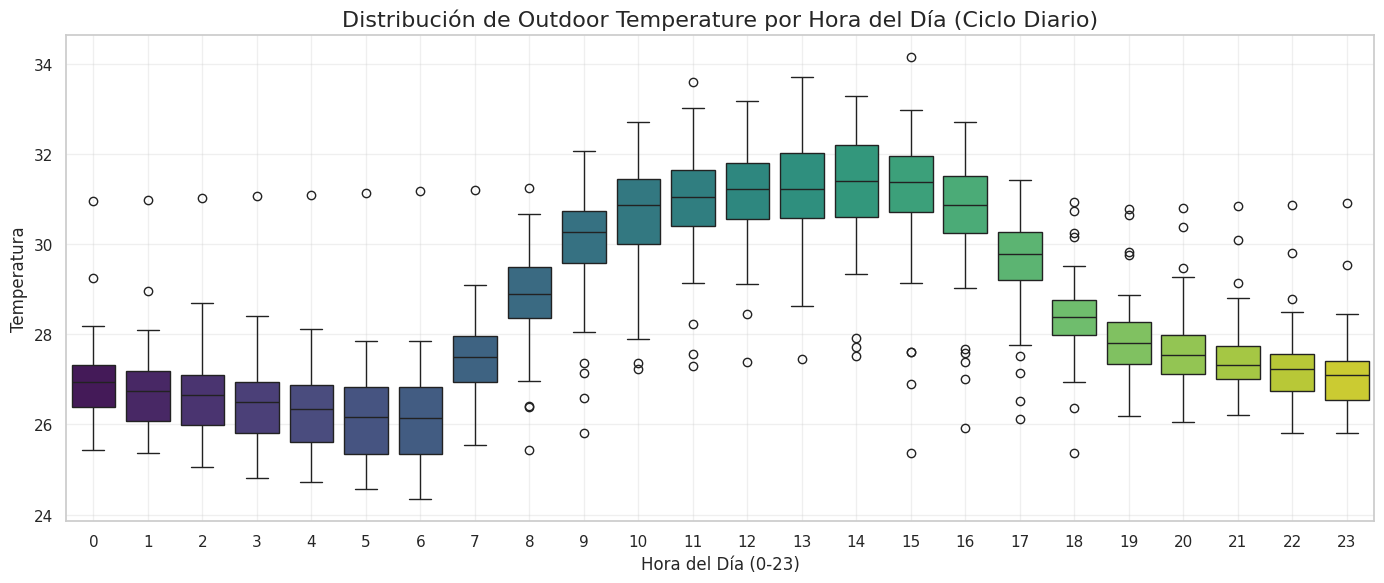

In [7]:
# Extraer la hora del índice para agrupar
df_resampled['hour'] = df_resampled.index.hour

plt.figure(figsize=(14, 6))
sns.boxplot(x='hour', y=TARGET_VAR, data=df_resampled, palette='viridis')
plt.title(f'Distribución de {TARGET_VAR.replace("_", " ").title()} por Hora del Día (Ciclo Diario)', fontsize=16)
plt.xlabel('Hora del Día (0-23)', fontsize=12)
plt.ylabel('Temperatura', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Eliminar la columna 'hour' para que no afecte el entrenamiento futuro
df_resampled.drop(columns=['hour'], inplace=True)

## 3. Fase de Preprocesamiento

### 3.1 Selección de Variables (Feature Selection)
Basados en el EDA, crearemos un modelo **Multivariante**. Predeciremos la temperatura basándonos en su propia historia y en variables clave que no sean redundantes.
Seleccionamos:
1. `outdoor_temperature` (Target)
2. `humidity` (Fuerte correlación negativa)
3. `solar_radiation` (Fuerte correlación positiva)
4. `wind_speed` (Aporta información dinámica sobre frentes de viento que enfrían)

In [8]:
# Selección de variables estratégicas
features = ['outdoor_temperature', 'humidity', 'solar_radiation', 'wind_speed']

# Validar que existan, si hay algún error de nombre, usar la temperatura al menos
features = [f for f in features if f in df_resampled.columns]
df_model = df_resampled[features].copy()

# División Cronológica (80% Entrenamiento, 20% Prueba)
train_size = int(len(df_model) * 0.8)
train_df = df_model.iloc[:train_size]
test_df = df_model.iloc[train_size:]

print(f"Datos de Entrenamiento: {len(train_df)} registros")
print(f"Datos de Prueba: {len(test_df)} registros")

Datos de Entrenamiento: 1631 registros
Datos de Prueba: 408 registros


### 3.2 Escalado y Generación de Secuencias (Ventanas Deslizantes)
Las redes neuronales convergen más rápido si los datos están entre 0 y 1. Además, transformaremos nuestros datos 2D tabulares en tensores 3D usando el método de **Sliding Window** (Ventana Deslizante) tomando las últimas 24 horas para predecir la hora siguiente.

In [9]:
from sklearn.preprocessing import MinMaxScaler

# 1. Escalado de Datos
# Usamos un escalador para todas las features y uno específico para el Target
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Ajustamos solo con datos de entrenamiento para evitar 'Data Leakage' (Fuga de datos)
train_scaled = scaler_X.fit_transform(train_df)
test_scaled = scaler_X.transform(test_df)

# Ajustamos el scaler del target (columna 0 es outdoor_temperature)
scaler_y.fit(train_df[[TARGET_VAR]])

# 2. Función generadora de secuencias (Sliding Window)
def create_sequences(dataset, target_col_index, sequence_length):
    X, y = [], []
    for i in range(len(dataset) - sequence_length):
        # Toma 'sequence_length' horas pasadas de todas las variables
        X.append(dataset[i:(i + sequence_length), :])
        # Toma el valor a predecir de la hora siguiente (solo el target)
        y.append(dataset[i + sequence_length, target_col_index])
    return np.array(X), np.array(y)

# 3. Creación de las estructuras de datos (24 horas de memoria)
SEQ_LENGTH = 24
TARGET_COL_INDEX = 0 # outdoor_temperature está en la posición 0

X_train, y_train = create_sequences(train_scaled, TARGET_COL_INDEX, SEQ_LENGTH)
X_test, y_test = create_sequences(test_scaled, TARGET_COL_INDEX, SEQ_LENGTH)

print("Forma de los tensores resultantes:")
print(f"X_train shape: {X_train.shape} (Muestras, Timesteps, Features)")
print(f"y_train shape: {y_train.shape} (Muestras objetivo)")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Forma de los tensores resultantes:
X_train shape: (1607, 24, 4) (Muestras, Timesteps, Features)
y_train shape: (1607,) (Muestras objetivo)
X_test shape: (384, 24, 4)
y_test shape: (384,)


## 4. Fase de Modelado (Deep Learning: RNN vs LSTM)

### 4.1 Arquitectura de los Modelos
Construiremos dos arquitecturas paralelas para evaluar su desempeño:
1. **SimpleRNN:** Una red recurrente básica.
2. **LSTM:** Red con memoria a corto y largo plazo.

Ambas tendrán:
* Una capa recurrente de 64 neuronas.
* Regularización `Dropout` del 20% (apaga aleatoriamente el 20% de las neuronas para obligar a la red a generalizar y no memorizar los datos).
* Una capa densa oculta (Dense) de 32 neuronas con activación ReLU para extraer patrones no lineales.
* Una capa de salida (Dense) de 1 neurona (Predicción de la temperatura).

In [10]:
#!pip install tensorflow

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Definir la dimensionalidad de entrada (Timesteps = 24, Features = 4)
input_shape = (X_train.shape[1], X_train.shape[2])

# ==========================================
# MODELO 1: Simple RNN
# ==========================================
rnn_model = Sequential([
    SimpleRNN(units=64, input_shape=input_shape, return_sequences=False),
    Dropout(0.2), # Apaga el 20% de las conexiones para evitar overfitting
    Dense(units=32, activation='relu'),
    Dense(units=1) # Salida: Temperatura predicha (escalada)
])
rnn_model.compile(optimizer='adam', loss='mean_squared_error')

# ==========================================
# MODELO 2: LSTM
# ==========================================
lstm_model = Sequential([
    LSTM(units=64, input_shape=input_shape, return_sequences=False),
    Dropout(0.2),
    Dense(units=32, activation='relu'),
    Dense(units=1)
])
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# ==========================================
# CALLBACKS
# ==========================================
# Parada Temprana: Detiene el entrenamiento si el error de validación no mejora en 10 épocas,
# y restaura los pesos del mejor modelo encontrado.
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("Arquitecturas definidas correctamente.")
lstm_model.summary()

Arquitecturas definidas correctamente.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

### 4.2 Entrenamiento de los Modelos
Entrenaremos ambos modelos con los mismos datos y parámetros (Épocas, Tamaño de Lote). Guardaremos el historial de pérdida (*loss*) para comparar cómo aprende cada arquitectura.

In [12]:
EPOCHS = 50
BATCH_SIZE = 32

print("--- ENTRENANDO MODELO SimpleRNN ---")
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("\n--- ENTRENANDO MODELO LSTM ---")
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

--- ENTRENANDO MODELO SimpleRNN ---
Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0474 - val_loss: 0.0090
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0156 - val_loss: 0.0075
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0119 - val_loss: 0.0083
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0094 - val_loss: 0.0056
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0081 - val_loss: 0.0047
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0067 - val_loss: 0.0037
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0060 - val_loss: 0.0032
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0061 - val_loss: 0.0036
Epoch 9/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0054 - val_loss: 0.0031
Epoch 10/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0052 - val_loss: 0.0025
Epoch 11/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0047 - val_loss: 0.0028
Epoch 12/50
51/51 ━━━━━━━━━━━━━━━━━━━

### 4.3 Análisis de Convergencia (Curvas de Aprendizaje)
Comparamos gráficamente la pérdida de entrenamiento vs la de validación para ambos modelos. Un buen modelo debería mostrar una curva que desciende y se estabiliza de manera junta, sin que la línea de validación se dispare hacia arriba (lo cual indicaría Overfitting).

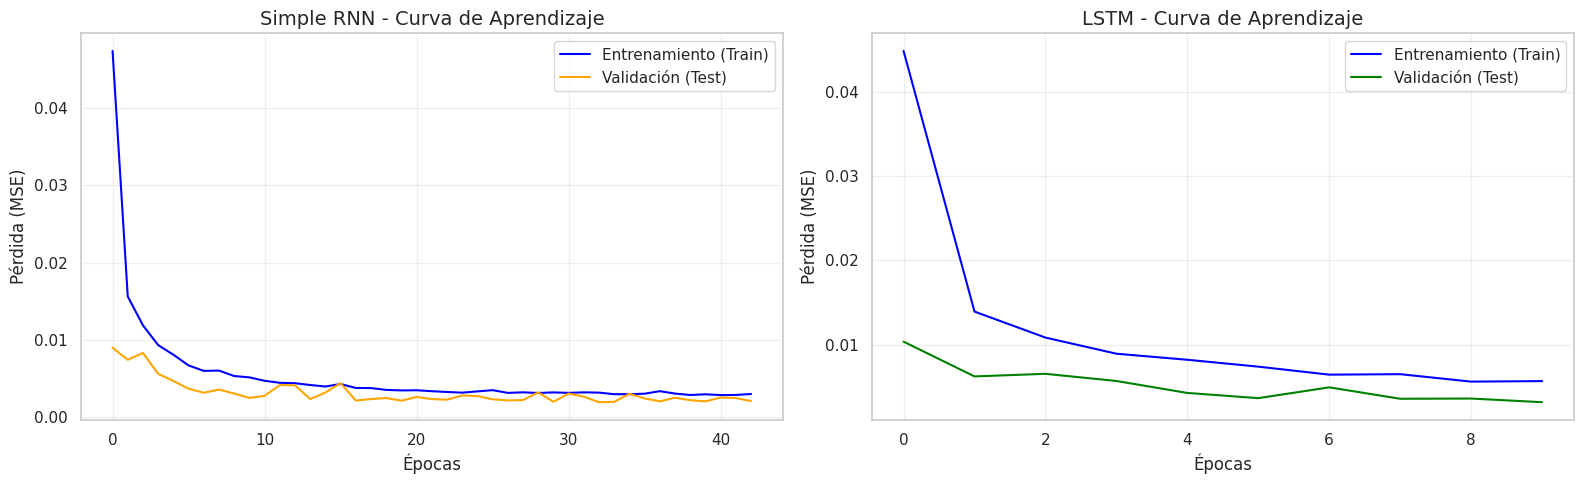

In [13]:
# Crear subgráficos para comparar RNN y LSTM
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico para SimpleRNN
axes[0].plot(history_rnn.history['loss'], label='Entrenamiento (Train)', color='blue')
axes[0].plot(history_rnn.history['val_loss'], label='Validación (Test)', color='orange')
axes[0].set_title('Simple RNN - Curva de Aprendizaje', fontsize=14)
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Pérdida (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico para LSTM
axes[1].plot(history_lstm.history['loss'], label='Entrenamiento (Train)', color='blue')
axes[1].plot(history_lstm.history['val_loss'], label='Validación (Test)', color='green')
axes[1].set_title('LSTM - Curva de Aprendizaje', fontsize=14)
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Pérdida (MSE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Fase de Evaluación y Predicciones Futuras (Toma de Decisiones)

### 5.1 Inversión del Escalado y Cálculo de Métricas (MAE y RMSE)
Para que los resultados aporten valor al negocio, los errores deben expresarse en unidades reales (Grados de temperatura).
* **MAE (Mean Absolute Error):** Nos dice por cuántos grados se equivoca el modelo en promedio.
* **RMSE (Root Mean Squared Error):** Penaliza los errores grandes. Si el modelo falla por mucho en una hora pico, el RMSE se disparará.

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Generar predicciones sobre el conjunto de prueba
rnn_preds = rnn_model.predict(X_test)
lstm_preds = lstm_model.predict(X_test)

# 2. Invertir el escalado (volver a grados reales)
# Utilizamos scaler_y que fue ajustado únicamente con la columna de temperatura
y_test_real = scaler_y.inverse_transform(y_test.reshape(-1, 1))
rnn_preds_real = scaler_y.inverse_transform(rnn_preds)
lstm_preds_real = scaler_y.inverse_transform(lstm_preds)

# 3. Calcular métricas
rnn_rmse = np.sqrt(mean_squared_error(y_test_real, rnn_preds_real))
rnn_mae = mean_absolute_error(y_test_real, rnn_preds_real)

lstm_rmse = np.sqrt(mean_squared_error(y_test_real, lstm_preds_real))
lstm_mae = mean_absolute_error(y_test_real, lstm_preds_real)

print("--- RENDIMIENTO DEL MODELO Simple RNN ---")
print(f"RMSE (Penalización de errores grandes): {rnn_rmse:.2f} grados")
print(f"MAE  (Error absoluto promedio):         {rnn_mae:.2f} grados")

print("\n--- RENDIMIENTO DEL MODELO LSTM ---")
print(f"RMSE (Penalización de errores grandes): {lstm_rmse:.2f} grados")
print(f"MAE  (Error absoluto promedio):         {lstm_mae:.2f} grados")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
--- RENDIMIENTO DEL MODELO Simple RNN ---
RMSE (Penalización de errores grandes): 0.44 grados
MAE  (Error absoluto promedio):         0.32 grados

--- RENDIMIENTO DEL MODELO LSTM ---
RMSE (Penalización de errores grandes): 1.00 grados
MAE  (Error absoluto promedio):         0.73 grados


### 5.2 Visualización de las Predicciones vs Realidad
Graficaremos una porción del conjunto de prueba (ej. 5 días, unas 120 horas) para ver qué tan bien se superponen las curvas de nuestras redes neuronales con lo que realmente ocurrió.

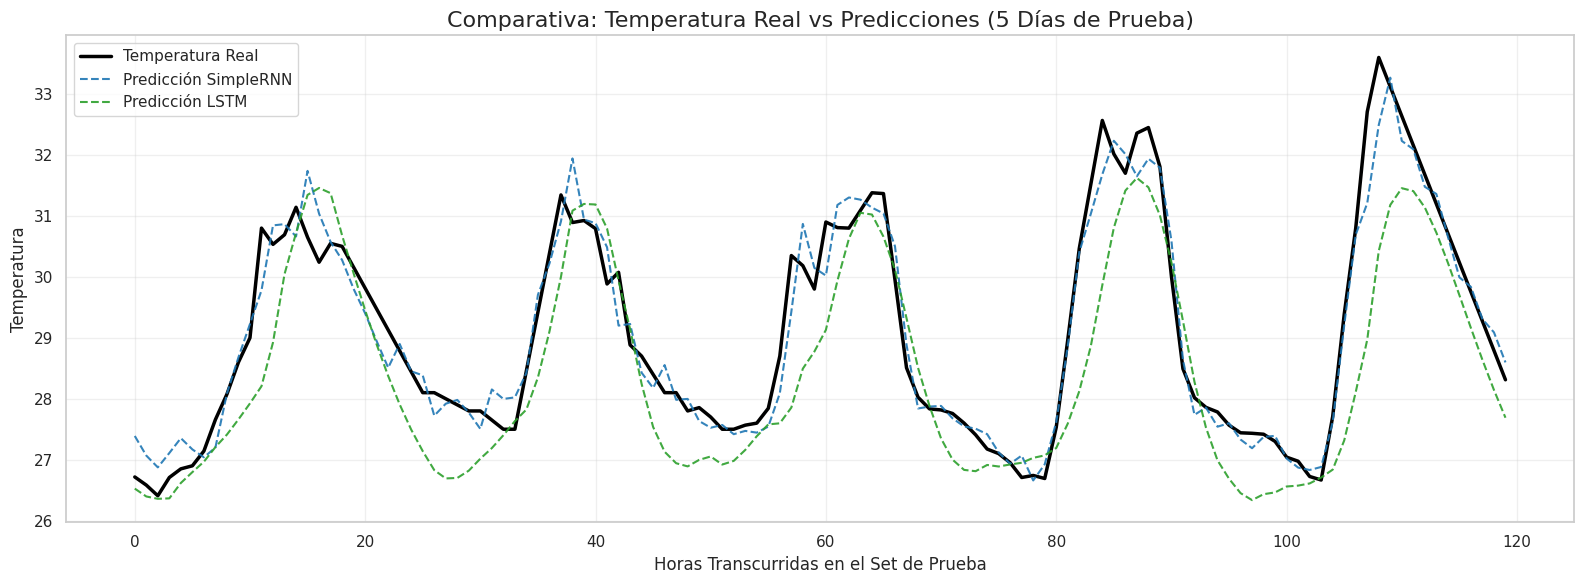

In [19]:
# Graficar una ventana de 100 horas para ver el detalle
DIAS_A_GRAFICAR = 5
HORAS = DIAS_A_GRAFICAR * 24

plt.figure(figsize=(16, 6))
plt.plot(y_test_real[:HORAS], label='Temperatura Real', color='black', linewidth=2.5)
plt.plot(rnn_preds_real[:HORAS], label='Predicción SimpleRNN', color='#1f77b4', linestyle='dashed', alpha=0.9)
plt.plot(lstm_preds_real[:HORAS], label='Predicción LSTM', color='#2ca02c', linestyle='dashed', alpha=0.9)

plt.title(f'Comparativa: Temperatura Real vs Predicciones ({DIAS_A_GRAFICAR} Días de Prueba)', fontsize=16)
plt.xlabel('Horas Transcurridas en el Set de Prueba', fontsize=12)
plt.ylabel('Temperatura', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

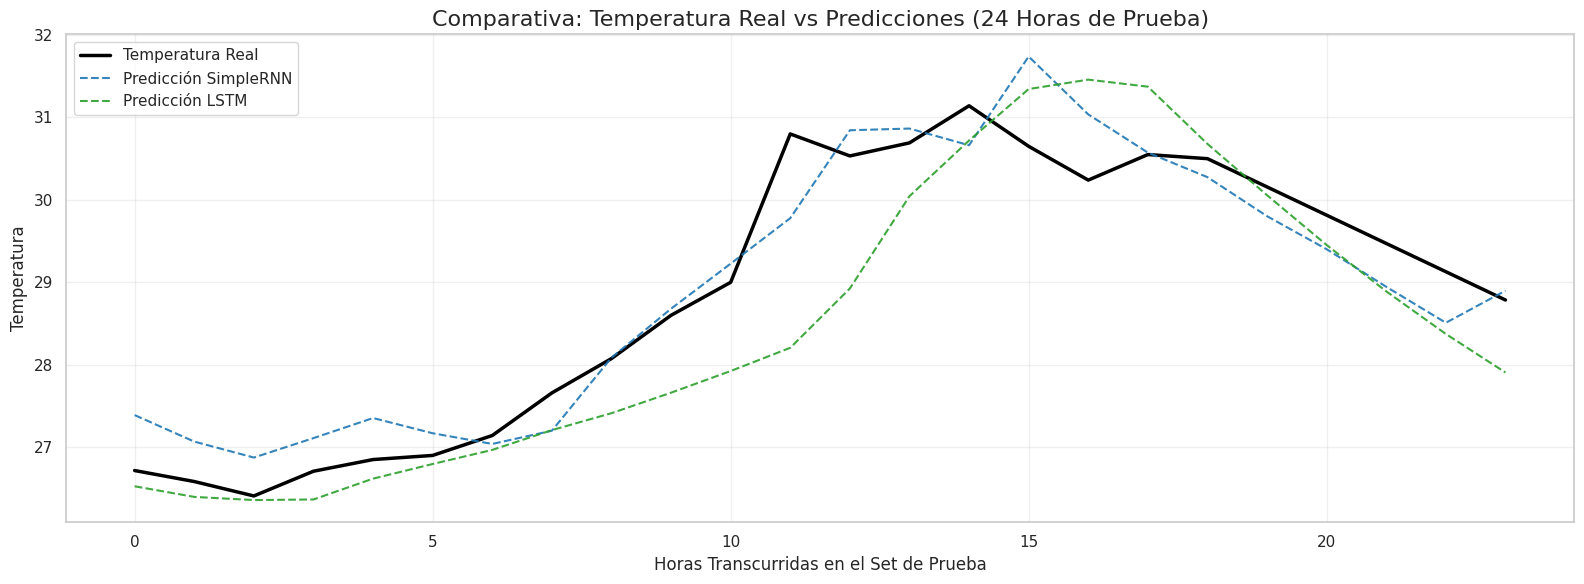

In [21]:
DIAS_A_GRAFICAR = 1
HORAS = DIAS_A_GRAFICAR * 24

plt.figure(figsize=(16, 6))
plt.plot(y_test_real[:HORAS], label='Temperatura Real', color='black', linewidth=2.5)
plt.plot(rnn_preds_real[:HORAS], label='Predicción SimpleRNN', color='#1f77b4', linestyle='dashed', alpha=0.9)
plt.plot(lstm_preds_real[:HORAS], label='Predicción LSTM', color='#2ca02c', linestyle='dashed', alpha=0.9)

plt.title(f'Comparativa: Temperatura Real vs Predicciones (24 Horas de Prueba)', fontsize=16)
plt.xlabel('Horas Transcurridas en el Set de Prueba', fontsize=12)
plt.ylabel('Temperatura', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Forecasting: Pronóstico hacia el futuro desconocido
Aquí radica el valor real del proyecto para la toma de decisiones. Tomaremos las últimas 24 horas conocidas de nuestro dataset y obligaremos a la red LSTM a predecir la hora 25. Luego, inyectaremos esa predicción como si fuera un dato real, para predecir la hora 26, y así iterativamente hasta tener **todo el día de mañana pronosticado**.

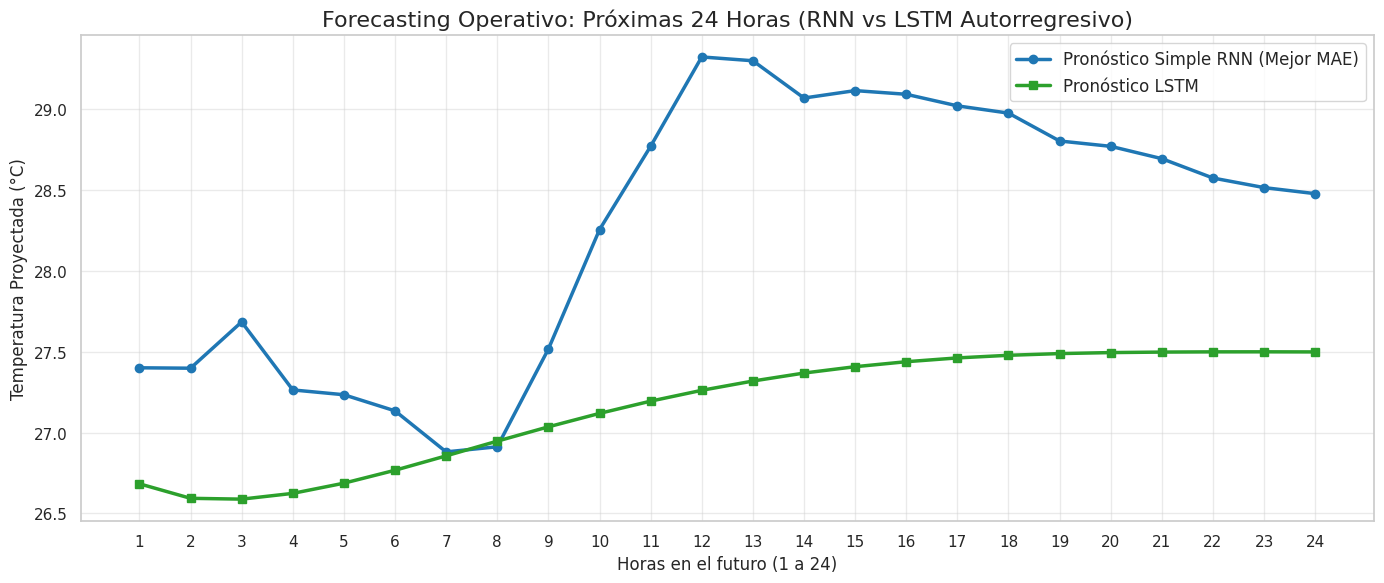

In [22]:
# 1. Tomar la última secuencia conocida (últimas 24 horas del dataset de prueba)
last_sequence = test_scaled[-SEQ_LENGTH:].copy()

# Crear copias independientes para que cada modelo itere sobre sus propias predicciones
current_seq_rnn = last_sequence.copy()
current_seq_lstm = last_sequence.copy()

future_preds_rnn = []
future_preds_lstm = []

# 2. Bucle iterativo para pronosticar 24 horas al futuro
for _ in range(24):

    # --- PREDICCIÓN CON SIMPLE RNN ---
    # Reformatear a 3D: [1 muestra, 24 timesteps, 4 features]
    seq_rnn_reshaped = current_seq_rnn.reshape(1, SEQ_LENGTH, current_seq_rnn.shape[1])
    next_temp_rnn = rnn_model.predict(seq_rnn_reshaped, verbose=0)[0][0]
    future_preds_rnn.append(next_temp_rnn)

    # Deslizar ventana RNN
    new_row_rnn = current_seq_rnn[-1].copy() # Copia las variables exógenas (viento, humedad, etc.) de la última hora
    new_row_rnn[TARGET_COL_INDEX] = next_temp_rnn # Actualiza solo la temperatura con la nueva predicción
    current_seq_rnn = np.append(current_seq_rnn[1:], [new_row_rnn], axis=0)


    # --- PREDICCIÓN CON LSTM ---
    # Reformatear a 3D
    seq_lstm_reshaped = current_seq_lstm.reshape(1, SEQ_LENGTH, current_seq_lstm.shape[1])
    next_temp_lstm = lstm_model.predict(seq_lstm_reshaped, verbose=0)[0][0]
    future_preds_lstm.append(next_temp_lstm)

    # Deslizar ventana LSTM
    new_row_lstm = current_seq_lstm[-1].copy()
    new_row_lstm[TARGET_COL_INDEX] = next_temp_lstm
    current_seq_lstm = np.append(current_seq_lstm[1:], [new_row_lstm], axis=0)


# 3. Invertir escalado de los pronósticos (Volver a Grados Celsius)
future_preds_rnn_real = scaler_y.inverse_transform(np.array(future_preds_rnn).reshape(-1, 1))
future_preds_lstm_real = scaler_y.inverse_transform(np.array(future_preds_lstm).reshape(-1, 1))

# 4. Graficar el pronóstico del día de mañana (Comparativa)
plt.figure(figsize=(14, 6))
plt.plot(range(1, 25), future_preds_rnn_real, color='#1f77b4', marker='o', linewidth=2.5, label='Pronóstico Simple RNN (Mejor MAE)')
plt.plot(range(1, 25), future_preds_lstm_real, color='#2ca02c', marker='s', linewidth=2.5, label='Pronóstico LSTM')

plt.title('Forecasting Operativo: Próximas 24 Horas (RNN vs LSTM Autorregresivo)', fontsize=16)
plt.xlabel('Horas en el futuro (1 a 24)', fontsize=12)
plt.ylabel('Temperatura Proyectada (°C)', fontsize=12)
plt.xticks(range(1, 25))
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Conclusiones Finales del Proyecto
1. **La Paradoja de la Complejidad (Navaja de Ockham en Deep Learning)**
El resultado más revelador de este experimento es que un modelo matemáticamente más complejo (LSTM) no siempre garantiza mejores resultados que uno más simple (Simple RNN).
Para este dataset en particular, que posee una fuerte estacionalidad (un ciclo diario muy marcado) y una longitud moderada tras el remuestreo horario, las compuertas adicionales de la LSTM (Forget, Input, Output) introdujeron una complejidad innecesaria en la superficie de error. Esto provocó que el optimizador se atascara prematuramente (underfitting). La Simple RNN, al tener la capacidad exacta y necesaria, modeló el patrón térmico con un error medio (MAE) de solo 0.32°C.
2. **El Impacto Crítico del Preprocesamiento (ETL y EDA)**
El éxito predictivo de la red neuronal no fue casualidad, sino el resultado directo de una ingeniería de datos rigurosa:
Aislamiento de la señal: Eliminar variables de sensores interiores y baterías evitó que la red aprendiera comportamientos humanos espurios.
Mitigación de la Multicolinealidad: Detectar en el EDA que la "sensación térmica" y la "temperatura" tenían una correlación del 0.97 nos permitió eliminar redundancias, ahorrando cómputo y evitando el sobreajuste.
Enfoque Multivariante Físico: Al alimentar la red con la Humedad (correlación negativa) y la Radiación Solar (correlación positiva), le dimos a la RNN el contexto meteorológico necesario para anticipar cambios bruscos.
3. **Limitaciones del Forecasting Autorregresivo**
Al observar la proyección hacia las futuras 24 horas, evidenciamos cómo el modelo iterativo alimenta su propia predicción (output) como entrada (input) para el siguiente paso. Esto demuestra que, aunque la RNN mantiene el ciclo físico del día perfectamente, la curva tiende a ser más "suave" que los datos reales debido a la acumulación del error paso a paso y al congelamiento de las variables exógenas (se asume que el viento y humedad del momento inicial se mantienen). Entender esto es vital para fijar el límite de confianza del pronóstico (ideal a corto plazo: 12-24 horas).
4. **Valor Agregado para la Toma de Decisiones (Business Value)**
Tener la capacidad de pronosticar la temperatura de las próximas 24 horas basándose en datos hiperlocales (una estación propia y no una API genérica de un aeropuerto lejano) abre la puerta a la automatización inteligente:
Eficiencia Energética: Los sistemas HVAC (Aire Acondicionado) de edificios corporativos o plantas industriales pueden programar su encendido pre-enfriando las instalaciones antes de la hora 9, justo cuando la curva azul muestra que la temperatura se disparará, reduciendo los picos de consumo eléctrico.
Agricultura de Precisión: Permite programar sistemas de riego automatizados en los valles térmicos (horas 1 a 6 de la predicción) para evitar la evaporación, o detonar alarmas de estrés térmico vegetal para el mediodía.
Logística y Cadena de Frío: Anticipar los picos de calor exactos del día siguiente permite a los despachadores planificar las rutas de los camiones refrigerados para minimizar el choque térmico al descargar mercancía sensible.